In [220]:
import numpy as np

from dynamics import coe2rv
from scipy.linalg import fractional_matrix_power, block_diag

In [221]:
class AtmosphericModel:
    """
    This class models the Earth's atmosphere as an exponential model.
    """

    def __init__(self):
        """
        Initialize atmospheric model parameters.
        """
        self.h_0 = np.array(
            [
                0.0,
                25.0,
                30.0,
                40.0,
                50.0,
                60.0,
                70.0,
                80.0,
                90.0,
                100.0,
                110.0,
                120.0,
                130.0,
                140.0,
                150.0,
                180.0,
                200.0,
                250.0,
                300.0,
                350.0,
                400.0,
                450.0,
                500.0,
                600.0,
                700.0,
                800.0,
                900.0,
                1000.0,
            ]
        ) * 1e3 # Reference altitude [m]

        self.rho_0 = (
            np.array(
                [
                    1.225,
                    3.899e-2,
                    1.774e-2,
                    3.972e-3,
                    1.057e-3,
                    3.206e-4,
                    8.770e-5,
                    1.905e-5,
                    3.396e-6,
                    5.297e-7,
                    9.661e-8,
                    2.438e-8,
                    8.484e-9,
                    3.845e-9,
                    2.070e-9,
                    5.464e-10,
                    2.789e-10,
                    7.248e-11,
                    2.418e-11,
                    9.518e-12,
                    3.725e-12,
                    1.585e-12,
                    6.967e-13,
                    1.454e-13,
                    3.614e-14,
                    1.170e-14,
                    5.245e-15,
                    3.019e-15,
                ]
            )
        )  # Reference density [kg / m^3]

        self.H = np.array(
            [
                7.249,
                6.349,
                6.682,
                7.554,
                8.382,
                7.714,
                6.549,
                5.799,
                5.382,
                5.877,
                7.263,
                9.473,
                12.636,
                16.149,
                22.523,
                29.740,
                37.105,
                45.546,
                53.628,
                53.298,
                58.515,
                60.828,
                63.822,
                71.835,
                88.667,
                124.64,
                181.05,
                268.00,
            ]
        ) * 1e3 # Scale height [m]

    def get_rho(self, h):
        """
        Returns the atmospheric density at the given altitude.

        Parameters:
        h (float): The altitude in m.

        Returns:
        float: The atmospheric density in kg / m^3.
        """
        # Find the index of the closest below altitude
        idx = 27 if h >= 1000e3 else np.argmax(h < self.h_0) - 2

        # Compute the density
        return self.rho_0[idx] * np.exp(-(h - self.h_0[idx]) / self.H[idx])

    def get_H(self, h):
        """
        Returns the atmospheric scale height at the given altitude.

        Parameters:
        h (float): The altitude in m.

        Returns:
        float: The atmospheric scale height in m.
        """
        # Find the index of the closest below altitude
        idx = 27 if h >= 1000e3 else np.argmax(h < self.h_0) - 2

        # Compute the scale height
        return self.H[idx]

In [222]:
n_x = 6
n_y = 3
K = 10
dt = 60.0
mu = 3.986004418e14 # m^3/s^2
J_2 = 0.00108262545
R_earth = 6378.1363e3
sidereal_day = 23 * 3600 + 56 * 60 + 4.09
omega = 2 * np.pi / sidereal_day
omega_vec = np.array([0, 0, omega])
C_drag = 2.22  # Drag coefficient
A_drag = 0.01  # Drag area [m^2]
m = 1.0
atm = AtmosphericModel()

In [223]:
def f_function(x_vec):
    x_dot_vec = np.zeros_like(x_vec)
    for i in range(int(x_vec.shape[0] / 6)):
        r_vec = x_vec[i * 6 : i * 6 + 3]  # Satellite position vector [m]
        x, y, z = r_vec
        r = np.linalg.norm(r_vec)  # Satellite position magnitude [m]
        r_dot_vec = x_vec[i * 6 + 3 : i * 6 + 6]  # Satellite velocity vector [m / s]

        # Compute contributions from Earth's gravitational force
        r_ddot_vec_grav = (-mu * r_vec / r**3)  # Acceleration due to gravity [m / s^2]
        
        r_ddot_vec_J2 = (
            -(3 * J_2 * mu * R_earth**2)
            / (2 * r**5)
            * np.array(
                [
                    (1 - 5 * z**2 / r**2) * x,
                    (1 - 5 * z**2 / r**2) * y,
                    (3 - 5 * z**2 / r**2) * z,
                ]
            )
        )
        
        # Compute contributions from atmospheric drag
        h = r - R_earth  # Altitude [km]
        rho_atm = atm.get_rho(h)  # Atmospheric density [kg / m^3]

        r_dot_vec_rel = r_dot_vec - np.cross(omega_vec, r_vec.reshape(-1)).reshape((3, 1))  # Relative velocity vector [m / s]
        r_dot_rel = np.linalg.norm(r_dot_vec_rel)  # Relative velocity magnitude [m / s]

        r_ddot_vec_drag = (
            -0.5
            * C_drag
            * A_drag
            / m
            * rho_atm
            * r_dot_rel
            * r_dot_vec_rel
        )
        
        # Superposition of all contributions
        x_dot_vec[i * 6 : i * 6 + 6] = np.concatenate((r_dot_vec, r_ddot_vec_grav + r_ddot_vec_J2 + r_ddot_vec_drag))
    return x_dot_vec

def f(x_old):
    k1 = f_function(x_old)
    k2 = f_function(x_old + dt / 2 * k1)
    k3 = f_function(x_old + dt / 2 * k2)
    k4 = f_function(x_old + dt * k3)
    return x_old + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

def F(x_vec):
    F = np.zeros((x_vec.shape[0], x_vec.shape[0]))
    for i in range(int(x_vec.shape[0] / 6)):
        r_vec = x_vec[i * 6 : i * 6 + 3]  # Satellite position vector [m]
        x, y, z = r_vec
        r = np.linalg.norm(r_vec)  # Satellite position magnitude [m]
        r_dot_vec = x_vec[
            i * 6 + 3 : i * 6 + 6
        ]  # Satellite velocity vector [km / s]

        # Compute contributions from Earth's gravitational force
        dr_ddot_vec_grav_dr_vec = (-mu * (np.eye(3) / r**3 - 3 * np.outer(r_vec, r_vec) / r**5))  # Jacobian of acceleration due to gravity w.r.t. position [s^{-2}]

        dr_ddot_vec_J2_dr_vec = (
            -(3 * J_2 * mu * R_earth**2)
            / (2 * r**9)
            * np.array(
                [
                    [
                        -4 * x**4
                        - 3 * x**2 * y**2
                        + 27 * x**2 * z**2
                        + y**4
                        - 3 * y**2 * z**2
                        - 4 * z**4,
                        -5 * x**3 * y - 5 * x * y**3 + 30 * x * y * z**2,
                        -15 * x**3 * z - 15 * x * y**2 * z + 20 * x * z**3,
                    ],
                    [
                        -5 * x**3 * y - 5 * x * y**3 + 30 * x * y * z**2,
                        x**4
                        - 3 * x**2 * y**2
                        - 3 * x**2 * z**2
                        - 4 * y**4
                        + 27 * y**2 * z**2
                        - 4 * z**4,
                        -15 * x**2 * y * z - 15 * y**3 * z + 20 * y * z**3,
                    ],
                    [
                        -15 * x**3 * z - 15 * x * y**2 * z + 20 * x * z**3,
                        -15 * x**2 * y * z - 15 * y**3 * z + 20 * y * z**3,
                        3 * x**4
                        + 6 * x**2 * y**2
                        - 24 * x**2 * z**2
                        + 3 * y**4
                        - 24 * y**2 * z**2
                        + 8 * z**4,
                    ],
                ]
            )
        ).reshape(
            (3, 3)
        )
        
        # Compute contributions from atmospheric drag
        h = r - R_earth  # Altitude [km]
        rho_atm = atm.get_rho(h)  # Atmospheric density [kg / km^3]
        drho_atm_dr_vec = (
            -rho_atm / atm.get_H(h) * r_vec.T / r
        )  # Jacobian of atmospheric density w.r.t. position [kg / km^4]

        r_dot_vec_rel = r_dot_vec - np.cross(
            omega_vec, r_vec.reshape(-1)
        ).reshape(
            (3, 1)
        )  # Relative velocity vector [km / s]
        r_dot_rel = np.linalg.norm(
            r_dot_vec_rel
        )  # Relative velocity magnitude [km / s]
        dr_dot_vec_rel_dr_vec = np.array(
            [[0, omega, 0], [-omega, 0, 0], [0, 0, 0]]
        )  # Jacobian of relative velocity w.r.t. position [s^{-1}]
        
        dr_ddot_vec_drag_dr_vec = (
            -0.5
            * C_drag
            * A_drag
            / m
            * (
                r_dot_rel * r_dot_vec_rel * drho_atm_dr_vec
                + rho_atm
                * (
                    r_dot_vec_rel * r_dot_vec_rel.T / r_dot_rel
                    + r_dot_rel * np.eye(3)
                )
                * dr_dot_vec_rel_dr_vec
            )
        )  # Jacobian of acceleration due to atmospheric drag w.r.t. position [s^{-2}]
        dr_ddot_vec_drag_dr_dot_vec = (
            -0.5
            * C_drag
            * A_drag
            / m
            * rho_atm
            * (r_dot_vec_rel * r_dot_vec_rel.T / r_dot_rel + r_dot_rel * np.eye(3))
        )
            
        # Superposition of all contributions
        F[i * 6 : i * 6 + 3, i * 6 + 3 : i * 6 + 6] = np.eye(3)
        F[i * 6 + 3 : i * 6 + 6, i * 6 : i * 6 + 3] = dr_ddot_vec_grav_dr_vec + dr_ddot_vec_J2_dr_vec + dr_ddot_vec_drag_dr_vec
        F[i * 6 + 3 : i * 6 + 6, i * 6 + 3 : i * 6 + 6] = dr_ddot_vec_drag_dr_dot_vec

    return F

In [224]:
def h(x_vec):
    return x_vec[0:3] # Normalize the position measurements

def H(x):
    H = np.zeros((3, 6))
    H[0:3, 0:3] = np.eye(3)
    return H

In [225]:
def r_function(Q, R, X, Y):
    r = np.zeros(((n_x + n_y) * K, 1))
    for k in range(K):
        x_k = X[n_x * k:n_x * (k + 1)]
        x_k_1 = X[n_x * (k + 1):n_x * (k + 2)]
        y_k = Y[:, :, k]
        r[n_x * k:n_x * (k + 1), :] = fractional_matrix_power(Q, -1/2) @ (x_k_1 - f(x_k))
        r[n_x * (k + 1):n_x * (k + 1) + n_y, :] = fractional_matrix_power(R, -1/2) @ (h(x_k) - y_k)
    return r

def J_jacobian(Q, R, X):
    J = np.zeros(((n_x + n_y) * K, n_x * (K + 1)))
    for k in range(K):
        x_k = X[n_x * k:n_x * (k + 1)]
        J[n_x * k:n_x * (k + 1), n_x * k:n_x * (k + 1)] = -fractional_matrix_power(Q, -1/2) @ F(x_k)
        J[n_x * k:n_x * (k + 1), n_x * (k + 1):n_x * (k + 2)] = fractional_matrix_power(Q, -1/2)
        J[n_x * (k + 1):n_x * (k + 1) + n_y, n_x * k:n_x * (k + 1)] = -fractional_matrix_power(R, -1/2) @ H(x_k)
    return J

def cost_function(Q, R, X, Y):
    r = r_function(Q, R, X, Y)
    return np.linalg.norm(r)**2

In [226]:
def line_search(Q, R, x_bold_i, delta_x, Y, alpha=0.1, beta=0.7, max_iter=50):
    t = 1
    cost_bold_i = cost_function(Q, R, x_bold_i, Y)
    for _ in range(max_iter):
        x_pred_i = x_bold_i - t * delta_x
        cost_pred_i = cost_function(Q, R, x_pred_i, Y)
        if cost_pred_i <= cost_bold_i - alpha * t * (delta_x.T @ delta_x):
            return t
        t *= beta
    return t

In [227]:
X_true = np.zeros((n_x, 1, K + 1))
X_true[:, :, 0] = coe2rv(semi_major_axis=6903.50e3, eccentricity=0.0011, inclination=np.deg2rad(97.49), argument_of_periapsis=np.deg2rad(0.0), longitude_of_ascending_node=np.deg2rad(0.0), true_anomaly=np.deg2rad(0.0)).reshape(6, 1) * 1e3
for k in range(K):
    X_true[:, :, k + 1] = f(X_true[:, :, k])

r = 1e-1
R = r**2 * np.eye(n_y)
Y = np.zeros((n_y, 1, K))
for k in range(K):
    Y[:, :, k] = h(X_true[:, :, k]) + np.sqrt(R) @ np.random.randn(n_y, 1)
    
q_chief_pos = 1e-1  # [m]
q_chief_vel = 1e-2  # [m / s]
Q = block_diag(q_chief_pos**2 * np.eye(3), q_chief_vel**2 * np.eye(3))
X_est = np.ones_like(X_true)
for k in range(K + 1):
    X_est[:, :, k] = X_true[:, :, k] + np.sqrt(Q) @ np.random.randn(6, 1)

# Solution
x_0 = np.vstack([X_est[:, :, k] for k in range(K + 1)])
lambda_0 = 1.0

x_bold_i = x_0
lambda_i = lambda_0
i = 0
epsilon = 1e-6
max_iter = 100

grad_i_norms = []
costs = []
lambdas_i = []

while i < max_iter:
    r = r_function(Q, R, x_bold_i, Y)
    J = J_jacobian(Q, R, x_bold_i)

    # For plotting the results
    grad_i_norm = np.linalg.norm(J.T @ r)
    grad_i_norms.append(grad_i_norm)
    costs.append(cost_function(Q, R, x_bold_i, Y))
    lambdas_i.append(lambda_i)

    if grad_i_norm < epsilon:
        print(f"STOOOOP\nIteration {i}\nGrad_i_norm = {grad_i_norm}\nx_pred_i cost = {cost_function(Q, R, x_pred_i, Y)} | x_bold_i cost = {cost_function(Q, R, x_bold_i, Y)}\nlambda_i = {lambda_i}\n")
        break

    # Solve for the update step
    delta_x = np.linalg.inv(J.T @ J + lambda_i * np.eye(J.shape[1])) @ J.T @ r

    x_pred_i = x_bold_i - delta_x
    

    print(f"Iteration {i}\nGrad_i_norm = {grad_i_norm}\nx_pred_i cost = {cost_function(Q, R, x_pred_i, Y)} | x_bold_i cost = {cost_function(Q, R, x_bold_i, Y)}\nlambda_i = {lambda_i}\n")
    
    if cost_function(Q, R, x_pred_i, Y,) < cost_function(Q, R, x_bold_i, Y):
        x_bold_i = x_pred_i
        lambda_i *= 0.7
    else:
        lambda_i *= 2.0
        
    # alpha = line_search(Q, R, x_bold_i, delta_x, Y)
    
    # x_pred_i = x_bold_i - alpha * delta_x

    i += 1
    
X_est = x_bold_i.reshape(K + 1, 1, 6).T

print("Converged to:", x_bold_i)
print("Number of iterations:", i)
print("Final cost:", costs[-1])
print("Final grad norm:", grad_i_norms[-1])
print("RMSE:", np.sqrt(np.mean(np.linalg.norm(X_est[:3, :, :] - X_true[:3, :, :], axis=0)**2)))

Iteration 0
Grad_i_norm = 884.7675648020944
x_pred_i cost = 222956.33811916475 | x_bold_i cost = 872.3100577705742
lambda_i = 1.0

Iteration 1
Grad_i_norm = 884.7675648020944
x_pred_i cost = 202361.57832694938 | x_bold_i cost = 872.3100577705742
lambda_i = 2.0

Iteration 2
Grad_i_norm = 884.7675648020944
x_pred_i cost = 173782.1910615188 | x_bold_i cost = 872.3100577705742
lambda_i = 4.0

Iteration 3
Grad_i_norm = 884.7675648020944
x_pred_i cost = 140025.12337614558 | x_bold_i cost = 872.3100577705742
lambda_i = 8.0

Iteration 4
Grad_i_norm = 884.7675648020944
x_pred_i cost = 105105.09622194829 | x_bold_i cost = 872.3100577705742
lambda_i = 16.0

Iteration 5
Grad_i_norm = 884.7675648020944
x_pred_i cost = 72144.78019034777 | x_bold_i cost = 872.3100577705742
lambda_i = 32.0

Iteration 6
Grad_i_norm = 884.7675648020944
x_pred_i cost = 44062.79020627111 | x_bold_i cost = 872.3100577705742
lambda_i = 64.0

Iteration 7
Grad_i_norm = 884.7675648020944
x_pred_i cost = 23352.04055263551 | x_b

In [228]:
def get_yticks_labels(yticks, also_get_exp=True):
    ytick_labels = []
    if also_get_exp:
        exponent = int(np.floor(np.log10(yticks[-1])))
        for tick in yticks:
            mantissa = tick / 10**exponent
            ytick_labels.append(f'\${mantissa:.2f}\$')
        return ytick_labels, exponent
    else:
        for tick in yticks:
            exponent = int(np.floor(np.log10(tick)))
            ytick_labels.append(rf'\$10^{exponent}\$')
        return ytick_labels

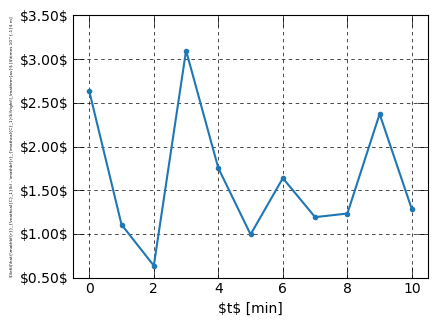

In [246]:
import matplotlib.pyplot as plt

# Use LaTeX for rendering text
# plt.rcParams['text.usetex'] = True
plt.rcParams['svg.fonttype'] = 'none'

deviations = np.linalg.norm(X_est[:3, :, :] - X_true[:3, :, :], axis=0).reshape(-1, 1)
time = np.arange(K + 1) * dt

fig, ax = plt.subplots(1, 1, figsize=(6.4 * 0.7, 4.8 * 0.7))

plt.plot(time / dt, deviations, '.-')
plt.xlabel(r'\$t\$ [min]')

# Retrieve and format yticks
yticks = ax.get_yticks()
yticks_labels, exponent = get_yticks_labels(yticks)
plt.yticks(yticks, yticks_labels)
plt.ylabel(rf'\$\left\|\hat{{\mathbf{{r}}}}_{{\mathcal{{C}}_1}}(k) - \mathbf{{r}}_{{\mathcal{{C}}_1}}(k)\right\|_\mathrm{{av}}\$ [\$\times 10^{{{exponent}}}\$ m]', fontsize=3)
plt.tick_params(axis='both', which='both', direction='in', length=8, width=0.5)
plt.tick_params(axis='x', which='both', top=True)
plt.tick_params(axis='y', which='both', right=True)
plt.grid(linestyle=(0, (5, 5)), color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("../../../Articles/Article 6/Images/absolute_error_LM.svg", format='svg')

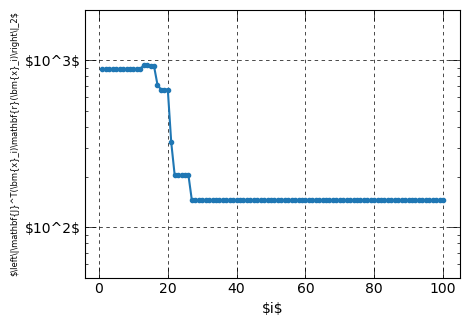

In [258]:
iterations = np.arange(max_iter) + 1

fig, ax = plt.subplots(1, 1, figsize=(6.4 * 0.75, 4.8 * 0.7))

plt.semilogy(iterations, grad_i_norms, '.-')
plt.xlabel(r'\$i\$')
yticks = ax.get_yticks()
yticks_labels = get_yticks_labels(yticks, also_get_exp=False)
plt.yticks(yticks, yticks_labels)
plt.ylim([5e1, 2e3])
plt.ylabel(r'\$\left\|\mathbf{J}^T(\bm{x}_i)\mathbf{r}(\bm{x}_i)\right\|_2\$', fontsize=6)
plt.tick_params(axis='both', which='minor', direction='in', length=2, width=0.5)
plt.tick_params(axis='both', which='major', direction='in', length=8, width=0.5)
plt.tick_params(axis='x', which='both', top=True)
plt.tick_params(axis='y', which='both', right=True)
plt.grid(linestyle=(0, (5, 5)), color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig("../../../Articles/Article 6/Images/grad_norms_i_LM.svg", format='svg')